In [2]:
import bibliotecas_e_modelos.ledo as ld
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import json

In [8]:
df = pd.read_csv("data/train_data.csv")
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_renovated,lat,long,hous_val_amt,trend,trend_sq,house_age,was_renovated
0,7129300520,2014-10-13,221900.0,3,1,1180,5650,1.0,0,0,...,1180,0,0,47.5112,-122.257,175400.0,5,25,59,False
1,6414100192,2014-12-09,538000.0,3,2,2570,7242,2.0,0,0,...,2170,400,1991,47.7210,-122.319,225900.0,7,49,63,True
2,5631500400,2015-02-25,180000.0,2,1,770,10000,1.0,0,0,...,770,0,0,47.7379,-122.233,246600.0,9,81,82,False
3,2487200875,2014-12-09,604000.0,4,3,1960,5000,1.0,0,0,...,1050,910,0,47.5208,-122.393,280200.0,7,49,49,False
4,1954400510,2015-02-18,510000.0,3,2,1680,8080,1.0,0,0,...,1680,0,0,47.6168,-122.045,239850.0,9,81,28,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18559,263000018,2014-05-21,360000.0,3,2,1530,1131,3.0,0,0,...,1530,0,0,47.6993,-122.346,279200.0,0,0,5,False
18560,6600060120,2015-02-23,400000.0,4,2,2310,5813,2.0,0,0,...,2310,0,0,47.5107,-122.362,180100.0,9,81,1,False
18561,1523300141,2014-06-23,402101.0,2,1,1020,1350,2.0,0,0,...,1020,0,0,47.5944,-122.299,219400.0,1,1,5,False
18562,291310100,2015-01-16,400000.0,3,2,1600,2388,2.0,0,0,...,1600,0,0,47.5345,-122.069,308700.0,8,64,11,False


In [9]:
features = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "house_age"]
target = "price"
set_de_treino = df[features].copy()
set_de_treino["price"] = df["price"]
set_de_treino

,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,house_age,price
0,3,1,1180,5650,1180,0,59,221900.0
1,3,2,2570,7242,2170,400,63,538000.0
2,2,1,770,10000,770,0,82,180000.0
3,4,3,1960,5000,1050,910,49,604000.0
4,3,2,1680,8080,1680,0,28,510000.0
...,...,...,...,...,...,...,...,...
18559,3,2,1530,1131,1530,0,5,360000.0
18560,4,2,2310,5813,2310,0,1,400000.0
18561,2,1,1020,1350,1020,0,5,402101.0
18562,3,2,1600,2388,1600,0,11,400000.0


In [6]:
modelo, historico, score_base = ld.XGBoost(df, features, "price", 0, 1, 5, 2, 20, 0.2 )

In [ ]:

json.dump({"model": modelo, "pregressao": historico, "base_score": score_base}, open("modelo_XGB_V2.json", "w"))

In [3]:
modelo= json.load(open("bibliotecas_e_modelos/modelo_XGB_V2.json", "r", encoding="utf-8"))

In [4]:
XGB = modelo["model"]
melhorias = modelo["pregressao"]
base_score = modelo["base_score"]

In [5]:
teste = pd.read_csv("data/test_data.csv")

prev_list = list()
for i in teste.index:
    prev_list.append(ld.result_func_XGBoos(XGB, base_score, teste.loc[i]))

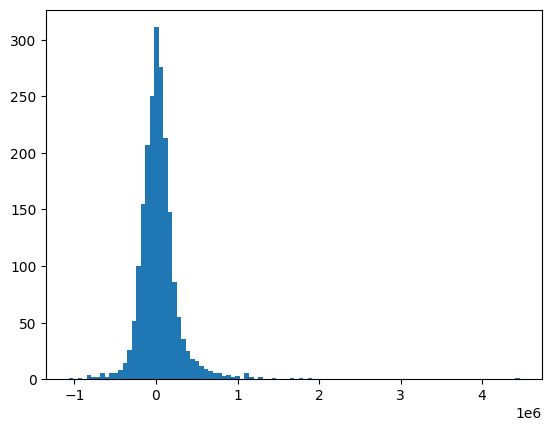

In [6]:
teste["prev"] = prev_list
teste["residual"] = teste["price"] - teste["prev"]
plt.hist(teste["residual"], bins = 100)
plt.show()

In [11]:
KNN_list = list()
vars = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "house_age", "lat", "long"]
for i in teste.index:
    KNN_list.append(ld.KNN_felipe(df, vars, teste.loc[i], 5))

<function matplotlib.pyplot.show(close=None, block=None)>

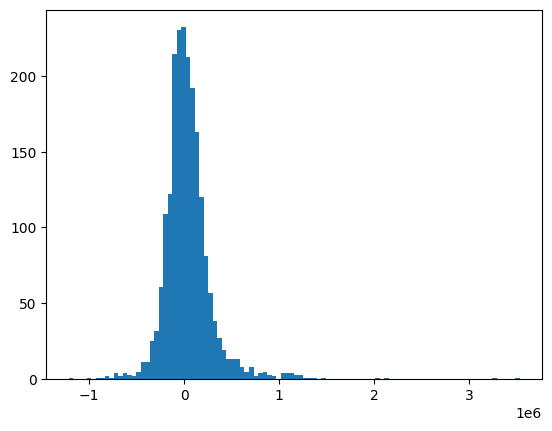

In [15]:
teste["KNN_prev"] = KNN_list
teste["KNN_res"] = teste["price"] - teste["KNN_prev"]

plt.hist(teste["KNN_res"], bins = 100)
plt.show

In [16]:
print(teste["residual"].mean(), teste["KNN_res"].mean())

34940.60061578458 41135.9490647482


In [17]:
val = pd.read_csv("data/val_data.csv")
val

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_renovated,lat,long,hous_val_amt,trend,trend_sq,house_age,was_renovated
0,9215400105,2015-04-28,450000.0,3,2,1250,5963,1.0,0,0,...,1250,0,0,47.6796,-122.301,282800.0,11,121,62,False
1,1695900060,2015-05-11,535000.0,4,1,1610,2982,1.5,0,0,...,1610,0,0,47.5870,-122.294,219400.0,12,144,90,False
2,9545240070,2015-04-28,660500.0,4,2,2010,9603,1.0,0,0,...,1440,570,0,47.5343,-122.054,308700.0,11,121,29,False
3,1432900240,2015-05-08,205000.0,3,1,1610,8579,1.0,0,0,...,1010,600,0,47.4563,-122.171,196900.0,12,144,53,False
4,1400300055,2015-04-28,425000.0,2,1,770,5040,1.0,0,0,...,770,0,0,47.5964,-122.299,219400.0,11,121,85,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,3304300300,2015-05-07,579950.0,4,3,2460,8643,2.0,0,0,...,2460,0,0,47.4828,-122.133,215200.0,12,144,4,False
960,6453550090,2015-05-05,861111.0,4,2,3650,7090,2.0,0,0,...,3650,0,0,47.6060,-122.052,239850.0,12,144,7,False
961,1760650820,2015-04-28,290000.0,3,2,1610,3764,2.0,0,0,...,1610,0,0,47.3589,-122.083,192000.0,11,121,3,False
962,3345700207,2015-05-02,608500.0,4,4,2850,5577,2.0,0,0,...,1950,900,0,47.5252,-122.192,209600.0,12,144,1,False
